In [4]:
import numpy as np
import pandas as pd
from datetime import date
from matplotlib import pyplot as plt
import marineHeatWaves as mhw

In [5]:
data = pd.read_csv('./OISST_data.csv', parse_dates=['t'])

In [6]:
data

,lon,lat,t,temp
0,-94.375,18.125,1982-01-01,26.750000
1,-88.125,18.125,1982-01-01,26.719999
2,-87.875,18.125,1982-01-01,27.020000
3,-87.625,18.125,1982-01-01,27.230000
4,-87.375,18.125,1982-01-01,27.280001
...,...,...,...,...
45441021,-80.875,31.125,2024-08-30,29.030001
45441022,-80.625,31.125,2024-08-30,29.010000
45441023,-80.375,31.125,2024-08-30,29.290001
45441024,-80.125,31.125,2024-08-30,29.830000


In [7]:
data['t'].iloc[1]

Timestamp('1982-01-01 00:00:00')

In [8]:
daily_mean = data.groupby('t')['temp'].mean()

In [9]:
daily_mean

t
1982-01-01    24.038300
1982-01-02    24.145485
1982-01-03    24.214038
1982-01-04    24.057881
1982-01-05    23.883641
                ...    
2024-08-26    30.696157
2024-08-27    30.682036
2024-08-28    30.635173
2024-08-29    30.578471
2024-08-30    30.510679
Name: temp, Length: 15578, dtype: float64

In [10]:
sst = daily_mean.values
sst

array([24.03829962, 24.1454851 , 24.21403839, ..., 30.63517312,
       30.57847102, 30.51067878])

In [11]:
dates = daily_mean.index
dates

DatetimeIndex(['1982-01-01', '1982-01-02', '1982-01-03', '1982-01-04',
               '1982-01-05', '1982-01-06', '1982-01-07', '1982-01-08',
               '1982-01-09', '1982-01-10',
               ...
               '2024-08-21', '2024-08-22', '2024-08-23', '2024-08-24',
               '2024-08-25', '2024-08-26', '2024-08-27', '2024-08-28',
               '2024-08-29', '2024-08-30'],
              dtype='datetime64[ns]', name='t', length=15578, freq=None)

In [12]:
t = pd.Series(daily_mean.index).apply(lambda x: x.toordinal())
t

0        723546
1        723547
2        723548
3        723549
4        723550
          ...  
15573    739124
15574    739125
15575    739126
15576    739127
15577    739128
Name: t, Length: 15578, dtype: int64

In [13]:
mhws, clim = mhw.detect(t, sst)

In [15]:
mhws.keys()

dict_keys(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration', 'duration_moderate', 'duration_strong', 'duration_severe', 'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var', 'intensity_cumulative', 'intensity_max_relThresh', 'intensity_mean_relThresh', 'intensity_var_relThresh', 'intensity_cumulative_relThresh', 'intensity_max_abs', 'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs', 'category', 'rate_onset', 'rate_decline', 'n_events'])

In [194]:
mhws

{'time_start': [723627,
  728057,
  728535,
  728554,
  729609,
  729626,
  729791,
  730542,
  730879,
  730960,
  732169,
  732425,
  732569,
  733094,
  733653,
  733668,
  733929,
  733986,
  734364,
  734576,
  734586,
  734629,
  735676,
  735700,
  735736,
  735906,
  735946,
  736114,
  736126,
  736225,
  736299,
  736311,
  736342,
  736396,
  736416,
  736525,
  736663,
  736741,
  736957,
  737003,
  737119,
  737211,
  737246,
  737281,
  737300,
  737330,
  737406,
  737423,
  737466,
  737501,
  737651,
  737669,
  737743,
  738075,
  738131,
  738291,
  738332,
  738342,
  738353,
  738420,
  738494,
  738529,
  738540,
  738559,
  738573,
  738605,
  738655,
  738682,
  738815,
  738833,
  738857,
  738948,
  738960,
  739014,
  739062],
 'time_end': [723631,
  728066,
  728541,
  728558,
  729617,
  729631,
  729798,
  730546,
  730883,
  730979,
  732173,
  732429,
  732573,
  733098,
  733659,
  733697,
  733948,
  733992,
  734380,
  734582,
  734607,
  734636,
  7

In [16]:
clim

{'thresh': array([24.67982169, 24.64046348, 24.60411792, ..., 30.09027632,
        30.07727345, 30.06338402]),
 'seas': array([23.99426727, 23.95664349, 23.91956143, ..., 29.53573673,
        29.52579903, 29.51493324]),
 'missing': array([False, False, False, ..., False, False, False])}

In [76]:
len(clim['seas'])

15578

In [92]:
dates

DatetimeIndex(['1982-01-01', '1982-01-02', '1982-01-03', '1982-01-04',
               '1982-01-05', '1982-01-06', '1982-01-07', '1982-01-08',
               '1982-01-09', '1982-01-10',
               ...
               '2024-08-21', '2024-08-22', '2024-08-23', '2024-08-24',
               '2024-08-25', '2024-08-26', '2024-08-27', '2024-08-28',
               '2024-08-29', '2024-08-30'],
              dtype='datetime64[ns]', name='t', length=15578, freq=None)

In [134]:
data_a_year = pd.DataFrame({
    "Date": dates[0:365].strftime("%m-%d"),
    'day_of_year': dates[0:365].dayofyear,
    'thresh': clim['thresh'][0:365],
    'baseline': clim['seas'][0:365],
    'missing': clim['missing'][0:365],
})

In [140]:
data_a_year

,Date,day_of_year,thresh,baseline,missing
0,01-01,1,24.679822,23.994267,False
1,01-02,2,24.640463,23.956643,False
2,01-03,3,24.604118,23.919561,False
3,01-04,4,24.568449,23.883055,False
4,01-05,5,24.533809,23.847250,False
...,...,...,...,...,...
360,12-27,361,24.878172,24.189949,False
361,12-28,362,24.837997,24.149976,False
362,12-29,363,24.798205,24.110350,False
363,12-30,364,24.758447,24.071132,False


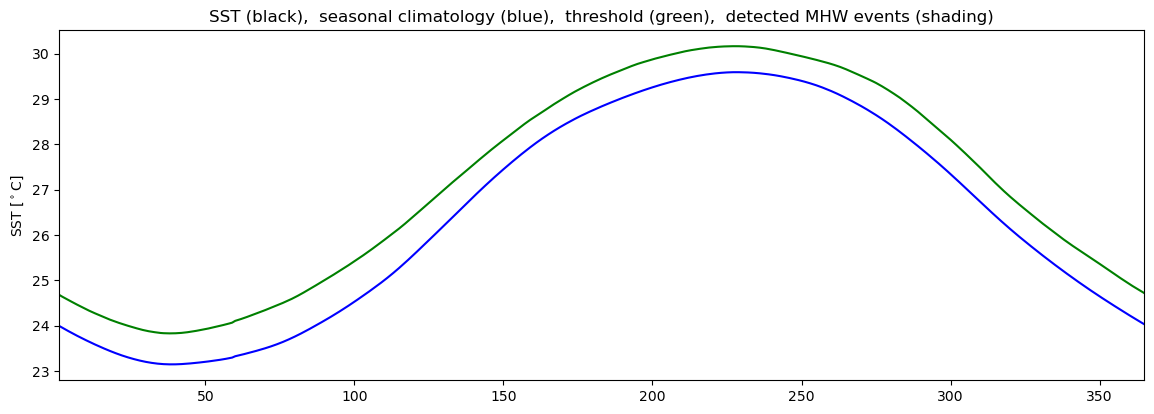

In [139]:
dates_a_year = list(data_a_year['day_of_year'])
thresh_a_year = data_a_year['thresh']
baseline_a_year = data_a_year['baseline']

plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
# plt.plot(dates_a_year, sst, 'k-')
plt.plot(dates_a_year, thresh_a_year, 'g-')
plt.plot(dates_a_year, baseline_a_year, 'b-')
plt.title('SST (black),  seasonal climatology (blue),  threshold (green),  detected MHW events (shading)')
plt.xlim(dates_a_year[0], dates_a_year[-1])
# plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')

plt.show()

In [188]:
def generate_random_sst():
    start_date = "2025-01-10"
    end_date = "2025-03-31"
    sst_min = 20.0
    sst_max = 30.0

    date_range = pd.date_range(start=start_date, end=end_date, freq="D")
    sst_values = np.random.uniform(sst_min, sst_max, len(date_range))

    df = pd.DataFrame({
        "Date": date_range,
        "SST": sst_values
    })
    return df

sst_to_predict = generate_random_sst()
sst_to_predict

,Date,SST
0,2025-01-10,23.394486
1,2025-01-11,20.283934
2,2025-01-12,25.755816
3,2025-01-13,27.829606
4,2025-01-14,22.427715
...,...,...
76,2025-03-27,24.178030
77,2025-03-28,26.651313
78,2025-03-29,26.263298
79,2025-03-30,24.038234


In [189]:
sst_to_predict['day_of_year'] = sst_to_predict['Date'].dt.dayofyear

In [190]:
predicted_mhw = {
    'date_start': [],
    'date_end': [],
    'duration': [],
    'start_day_of_year': [],
    'end_day_of_year': [],
}

categories = np.array(['Moderate', 'Strong', 'Severe', 'Extreme'])

one_duration = 0
one_date_start = None
one_date_end = None
one_start_day_of_year = None
one_end_day_of_year = None

for _, row in sst_to_predict.iterrows():
    index = row.day_of_year - 1
    row_sst = row.SST
    baseline_sst = data_a_year.iloc[index].baseline
    thresh_sst = data_a_year.iloc[index].thresh
    
    if row_sst > thresh_sst:
        
        if one_duration == 0:
            one_date_start = row.Date
            one_start_day_of_year = row.day_of_year
        one_duration += 1
        one_date_end = row.Date
        one_end_day_of_year = row.day_of_year
    else:
        if one_duration >= 5:
            predicted_mhw['date_start'].append(one_date_start)
            predicted_mhw['date_end'].append(one_date_end)
            predicted_mhw['duration'].append(one_duration)
            predicted_mhw['start_day_of_year'].append(one_start_day_of_year)
            predicted_mhw['end_day_of_year'].append(one_end_day_of_year)
        one_duration = 0

# In case last mhw doesn't end...
if one_duration >= 5:
    predicted_mhw['date_start'].append(one_date_start)
    predicted_mhw['date_end'].append(one_date_end)
    predicted_mhw['duration'].append(one_duration)    
    predicted_mhw['start_day_of_year'].append(one_start_day_of_year)
    predicted_mhw['end_day_of_year'].append(one_end_day_of_year)

In [191]:
predicted_mhw

{'date_start': [Timestamp('2025-02-24 00:00:00'),
  Timestamp('2025-03-05 00:00:00')],
 'date_end': [Timestamp('2025-03-01 00:00:00'),
  Timestamp('2025-03-09 00:00:00')],
 'duration': [6, 5],
 'start_day_of_year': [55, 64],
 'end_day_of_year': [60, 68]}

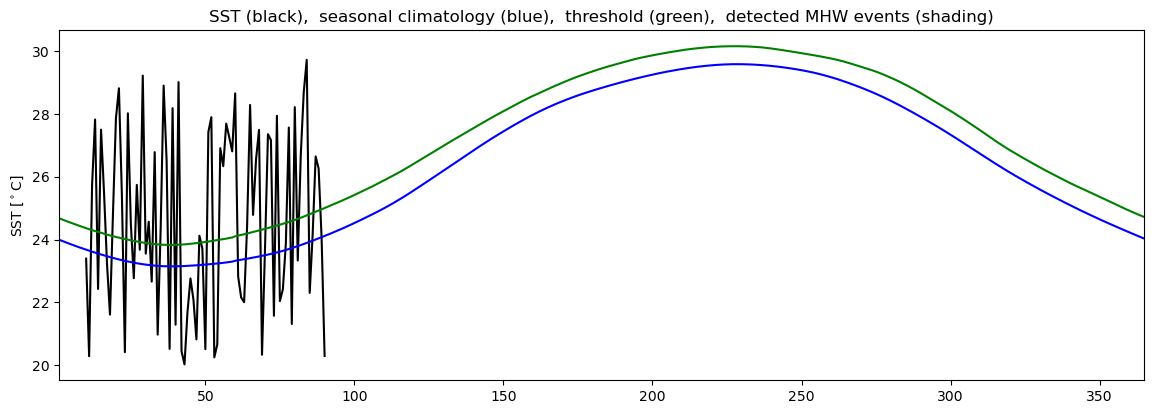

In [192]:
dates_a_year = list(data_a_year['day_of_year'])
thresh_a_year = data_a_year['thresh']
baseline_a_year = data_a_year['baseline']

plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(sst_to_predict['day_of_year'], sst_to_predict['SST'], 'k-')
plt.plot(dates_a_year, thresh_a_year, 'g-')
plt.plot(dates_a_year, baseline_a_year, 'b-')
plt.title('SST (black),  seasonal climatology (blue),  threshold (green),  detected MHW events (shading)')
plt.xlim(dates_a_year[0], dates_a_year[-1])
# plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')

plt.show()

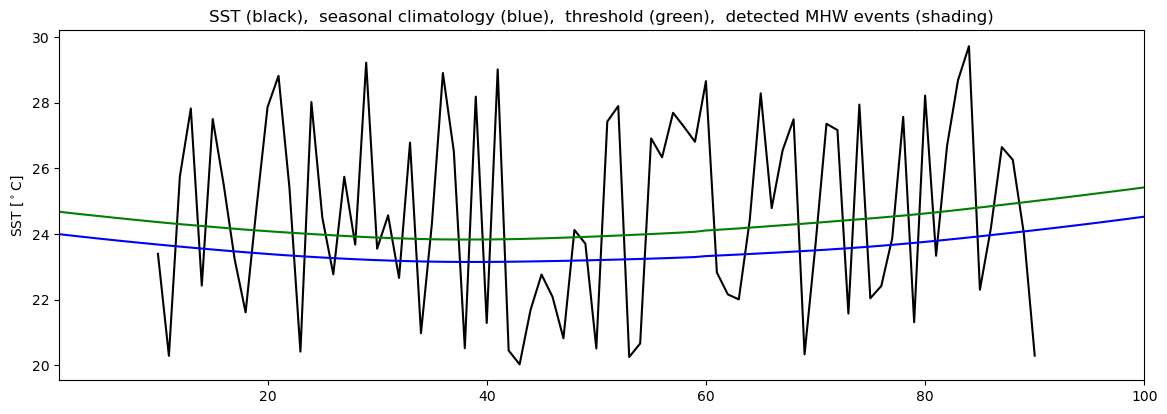

In [193]:

dates_a_year = list(data_a_year['day_of_year'])[0: 100]
thresh_a_year = data_a_year['thresh'][0: 100]
baseline_a_year = data_a_year['baseline'][0: 100]

plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(sst_to_predict['day_of_year'], sst_to_predict['SST'], 'k-')
plt.plot(dates_a_year, thresh_a_year, 'g-')
plt.plot(dates_a_year, baseline_a_year, 'b-')
plt.title('SST (black),  seasonal climatology (blue),  threshold (green),  detected MHW events (shading)')
plt.xlim(dates_a_year[0], dates_a_year[-1])
# plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')

plt.show()

In [115]:
# Next steps

# check if continuous date to predicte.
# leap year
# gaps between MHWs
# different categories (moderate, strong ....) Need rewrite Hobday's code
# different standards (other than 90th percentile, different duration threshold)

In [198]:
t_predict = pd.Series(sst_to_predict.Date).apply(lambda x: x.toordinal())
t_predict

0     739261
1     739262
2     739263
3     739264
4     739265
       ...  
76    739337
77    739338
78    739339
79    739340
80    739341
Name: Date, Length: 81, dtype: int64

In [200]:
sst_predict = sst_to_predict.SST
sst_predict 

0     23.394486
1     20.283934
2     25.755816
3     27.829606
4     22.427715
        ...    
76    24.178030
77    26.651313
78    26.263298
79    24.038234
80    20.291480
Name: SST, Length: 81, dtype: float64

In [204]:
mhws, clim = mhw.detect(t_predict, sst_predict, alternateClimatology=[t, sst])

/opt/anaconda3/lib/python3.11/site-packages/marineHeatWaves.py:306: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp[np.isnan(temp)] = clim['seas'][np.isnan(temp)]
/opt/anaconda3/lib/python3.11/site-packages/marineHeatWaves.py:314: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  exceed_bool[exceed_bool<=0] = False


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [78]:
data = pd.DataFrame({
    "Date": dates,
    "SST": sst_values
})

In [79]:
data["Year"] = data["Date"].dt.year
data["Day"] = data["Date"].dt.strftime("%m-%d")

In [81]:
df_pivot = data.pivot(index="Day", columns="Year", values="SST")

In [82]:
df_pivot

Year,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Day,,,,,,,,,,,,,,,,,,,,,
01-01,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,...,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267,23.994267
01-02,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,...,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643,23.956643
01-03,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,...,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561,23.919561
01-04,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,...,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055,23.883055
01-05,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,...,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250,23.847250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12-27,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,...,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,24.189949,NaN
12-28,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,...,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,24.149976,NaN
12-29,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,...,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,24.110350,NaN


In [83]:
df_pivot.to_excel("sst_data.xlsx", index=True)

In [48]:
mhws['n_events']

75

In [49]:
ev = np.argmax(mhws['intensity_max']) # Find largest event
ev

49

In [50]:
print ('Maximum intensity:', mhws['intensity_max'][ev], 'deg. C')
print ('Average intensity:', mhws['intensity_mean'][ev], 'deg. C')
print ('Cumulative intensity:', mhws['intensity_cumulative'][ev], 'deg. C-days')
print ('Duration:', mhws['duration'][ev], 'days')
print ('Start date:', mhws['date_start'][ev].strftime("%d %B %Y"))
print ('End date:', mhws['date_end'][ev].strftime("%d %B %Y"))

Maximum intensity: 1.8990694251563767 deg. C
Average intensity: 1.370728092265304 deg. C
Cumulative intensity: 71.27786079779581 deg. C-days
Duration: 52 days
Start date: 17 March 2020
End date: 07 May 2020


In [51]:
ev2 = 50

print ('Maximum intensity:', mhws['intensity_max'][ev2], 'deg. C')
print ('Average intensity:', mhws['intensity_mean'][ev2], 'deg. C')
print ('Cumulative intensity:', mhws['intensity_cumulative'][ev2], 'deg. C-days')
print ('Duration:', mhws['duration'][ev2], 'days')
print ('Start date:', mhws['date_start'][ev2].strftime("%d %B %Y"))
print ('End date:', mhws['date_end'][ev2].strftime("%d %B %Y"))

Maximum intensity: 0.7175398370331116 deg. C
Average intensity: 0.6640225785566276 deg. C
Cumulative intensity: 5.312180628453021 deg. C-days
Duration: 8 days
Start date: 14 August 2020
End date: 21 August 2020


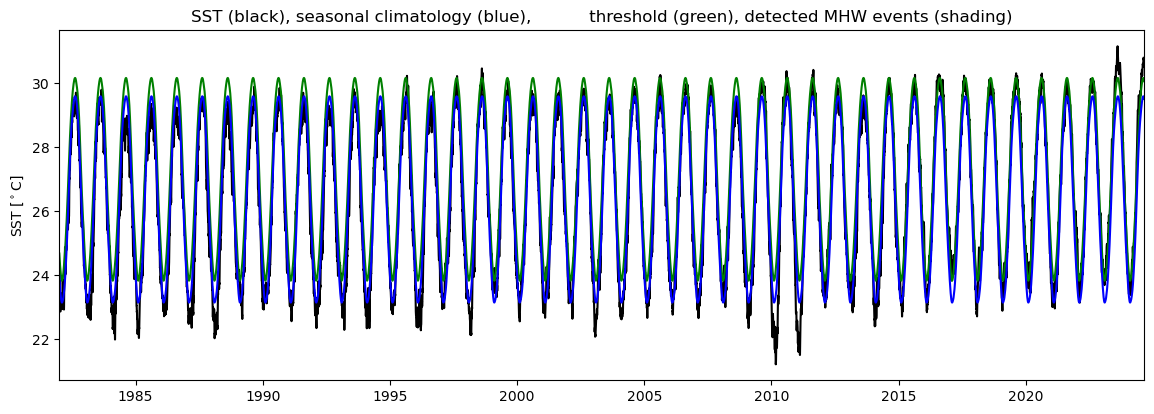

In [52]:
plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(dates, sst, 'k-')
plt.plot(dates, clim['thresh'], 'g-')
plt.plot(dates, clim['seas'], 'b-')
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[0], dates[-1])
plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')

plt.show()

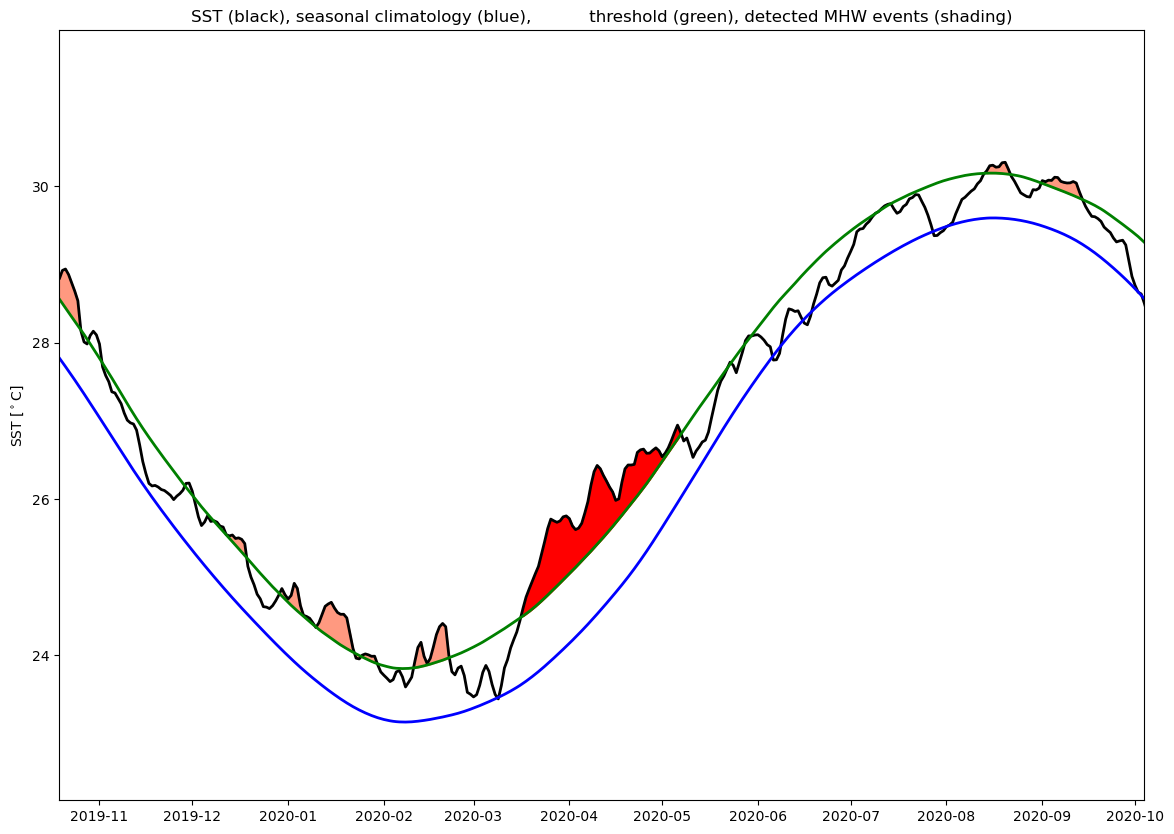

In [53]:
plt.figure(figsize=(14,10))
# Find indices for all ten MHWs before and after event of interest and shade accordingly
for ev0 in np.arange(ev-10, ev+11, 1):
    t1 = np.where(t==mhws['time_start'][ev0])[0][0]
    t2 = np.where(t==mhws['time_end'][ev0])[0][0]
#     print(t1, t2)
    plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                     color=(1,0.6,0.5))
# Find indices for MHW of interest and shade accordingly
t1 = np.where(t==mhws['time_start'][ev])[0][0]
t2 = np.where(t==mhws['time_end'][ev])[0][0]
plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                 color='r')
# Plot SST, seasonal cycle, threshold, shade MHWs with main event in red
plt.plot(dates, sst, 'k-', linewidth=2)
plt.plot(dates, clim['thresh'], 'g-', linewidth=2)
plt.plot(dates, clim['seas'], 'b-', linewidth=2)
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(date.fromordinal(mhws['time_start'][ev]-150), date.fromordinal(mhws['time_end'][ev]+150))
plt.ylim(clim['seas'].min() - 1, clim['seas'].max() + mhws['intensity_max'][ev] + 0.5)
plt.ylabel(r'SST [$^\circ$C]')
plt.show()

In [54]:
mhws.keys()

dict_keys(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration', 'duration_moderate', 'duration_strong', 'duration_severe', 'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var', 'intensity_cumulative', 'intensity_max_relThresh', 'intensity_mean_relThresh', 'intensity_var_relThresh', 'intensity_cumulative_relThresh', 'intensity_max_abs', 'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs', 'category', 'rate_onset', 'rate_decline', 'n_events'])

In [55]:
mhws['category']

['Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Moderate',
 'Strong',
 'Strong']

In [56]:
data

,lon,lat,t,temp
0,-94.375,18.125,1982-01-01,26.750000
1,-88.125,18.125,1982-01-01,26.719999
2,-87.875,18.125,1982-01-01,27.020000
3,-87.625,18.125,1982-01-01,27.230000
4,-87.375,18.125,1982-01-01,27.280001
...,...,...,...,...
45441021,-80.875,31.125,2024-08-30,29.030001
45441022,-80.625,31.125,2024-08-30,29.010000
45441023,-80.375,31.125,2024-08-30,29.290001
45441024,-80.125,31.125,2024-08-30,29.830000


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [66]:
# Filter the data for a specific date
oisst_data_filtered = data[data['t'] == datetime.datetime(2024, 8, 30)]
oisst_data_filtered

,lon,lat,t,temp
45438109,-94.375,18.125,2024-08-30,30.530001
45438110,-88.125,18.125,2024-08-30,30.540001
45438111,-87.875,18.125,2024-08-30,30.420000
45438112,-87.625,18.125,2024-08-30,30.320000
45438113,-87.375,18.125,2024-08-30,30.320000
...,...,...,...,...
45441021,-80.875,31.125,2024-08-30,29.030001
45441022,-80.625,31.125,2024-08-30,29.010000
45441023,-80.375,31.125,2024-08-30,29.290001
45441024,-80.125,31.125,2024-08-30,29.830000


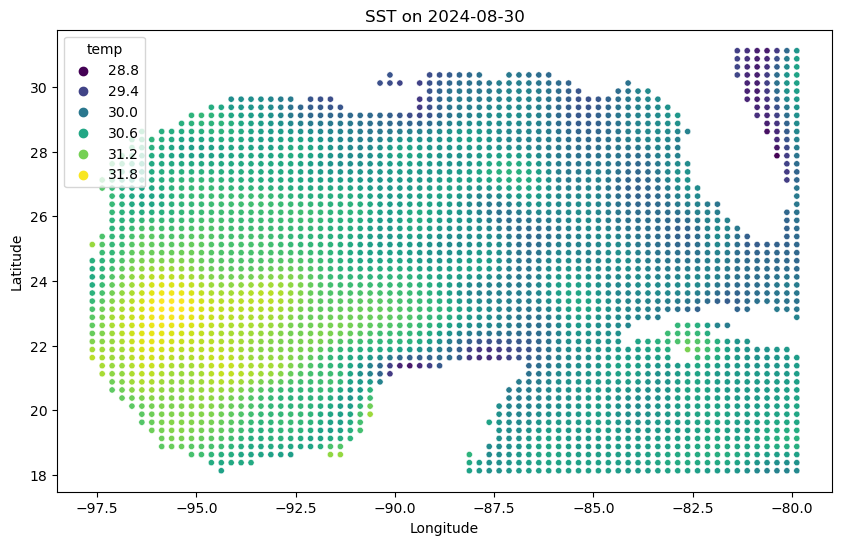

In [67]:
# Plot using seaborn and matplotlib
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=oisst_data_filtered, 
    x='lon', y='lat', hue='temp', palette='viridis', s=20
)
plt.title("SST on 2024-08-30")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
# plt.colorbar(label="SST (°C)")
plt.show()

In [71]:
month_data = data[data['t'].dt.to_period('M') == '2020-03']
month_data

,lon,lat,t,temp
40660063,-94.375,18.125,2020-03-01,24.240000
40660064,-88.125,18.125,2020-03-01,27.219999
40660065,-87.875,18.125,2020-03-01,27.170000
40660066,-87.625,18.125,2020-03-01,27.110001
40660067,-87.375,18.125,2020-03-01,27.049999
...,...,...,...,...
40750485,-80.875,31.125,2020-03-31,20.910000
40750486,-80.625,31.125,2020-03-31,21.090000
40750487,-80.375,31.125,2020-03-31,21.780001
40750488,-80.125,31.125,2020-03-31,22.930000


In [74]:
month_dates = month_data['t'].unique()
month_dates

<DatetimeArray>
['2020-03-01 00:00:00', '2020-03-02 00:00:00', '2020-03-03 00:00:00',
 '2020-03-04 00:00:00', '2020-03-05 00:00:00', '2020-03-06 00:00:00',
 '2020-03-07 00:00:00', '2020-03-08 00:00:00', '2020-03-09 00:00:00',
 '2020-03-10 00:00:00', '2020-03-11 00:00:00', '2020-03-12 00:00:00',
 '2020-03-13 00:00:00', '2020-03-14 00:00:00', '2020-03-15 00:00:00',
 '2020-03-16 00:00:00', '2020-03-17 00:00:00', '2020-03-18 00:00:00',
 '2020-03-19 00:00:00', '2020-03-20 00:00:00', '2020-03-21 00:00:00',
 '2020-03-22 00:00:00', '2020-03-23 00:00:00', '2020-03-24 00:00:00',
 '2020-03-25 00:00:00', '2020-03-26 00:00:00', '2020-03-27 00:00:00',
 '2020-03-28 00:00:00', '2020-03-29 00:00:00', '2020-03-30 00:00:00',
 '2020-03-31 00:00:00']
Length: 31, dtype: datetime64[ns]

In [98]:
temp_lst = month_data['temp']

sst_min = int(temp_lst.min())
sst_max = int(temp_lst.max()+1)

sst_min, sst_max

(13, 29)

In [ ]:
# References
# https://stackoverflow.com/questions/9401658/how-to-animate-a-scatter-plot
# https://www.youtube.com/watch?v=bNbN9yoEOdU
# https://matplotlib.org/basemap/stable/users/examples.html

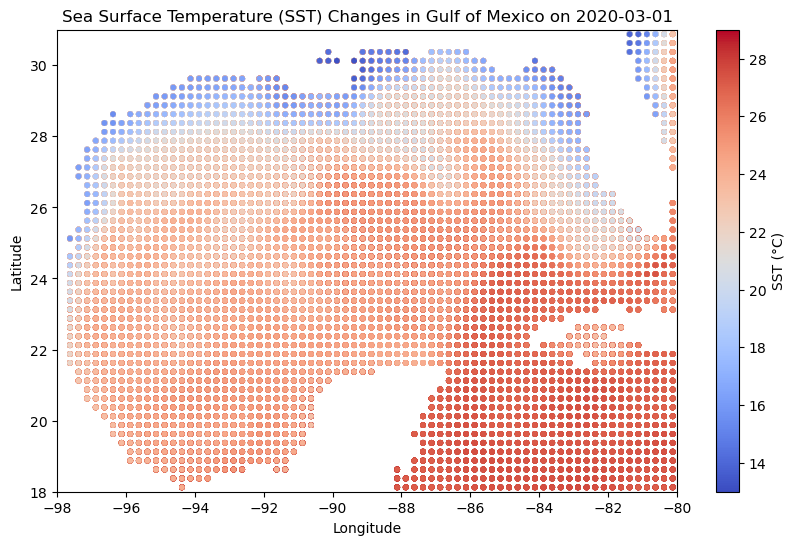

In [101]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim([-98, -80])
ax.set_ylim([18, 31])

scat = ax.scatter([], [], c=[], s=10, cmap='coolwarm', vmin=sst_min, vmax=sst_max)
cbar = plt.colorbar(scat, ax=ax, label='SST (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
    
def update(day):    
    current_day_data = month_data[month_data['t'] == day]
    
    scat = ax.scatter(current_day_data['lon'], current_day_data['lat'], 
                      c=current_day_data['temp'], s=10, cmap='coolwarm', vmin=sst_min, vmax=sst_max)
    plt.title(f'Sea Surface Temperature (SST) Changes in Gulf of Mexico on {day.strftime("%Y-%m-%d")}')


ani = animation.FuncAnimation(fig, update, frames=month_dates, interval=400)
ani.save('mhw_gom.gif', writer='pillow')

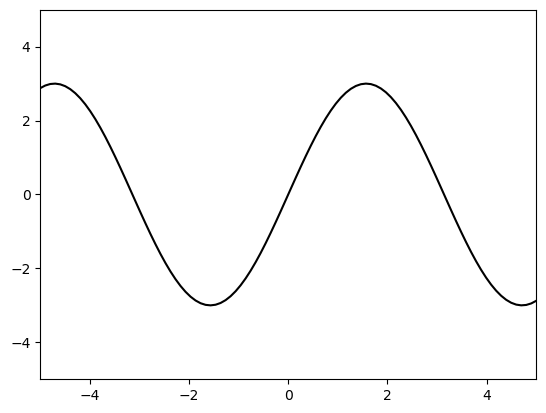

In [79]:
fig = plt.figure()
l, = plt.plot([], [], 'k-')

plt.xlim(-5, 5)
plt.ylim(-5, 5)

def func(x):
    return np.sin(x) * 3

metadata = dict(title='Movie', artist='Xiao')
writer = PillowWriter(fps=15, metadata=metadata)

xlist = []
ylist = []

with writer.saving(fig, "sinWave.gif", 100):
    for xval in np.linspace(-5, 5, 100):
        xlist.append(xval)
        ylist.append(func(xval))
        
        l.set_data(xlist, ylist)
        writer.grab_frame()